In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
with open('data/c11.txt', 'r') as f:
    print(f.read().split('\n'))

['0.0658', ' 0.0660', ' 0.0660', ' 0.0660', ' 0.0661', ' 0.0661', ' 0.0661', ' 0.0661', ' 0.0660', ' 0.0660', ' 0.0660', ' 0.0661', ' 0.0662', ' 0.0664', ' 0.0665', ' 0.0665', ' 0.0666', ' 0.0666', ' 0.0666', ' 0.0667', ' 0.0667', ' 0.0667', ' 0.0668', ' 0.0668', ' 0.0669', ' 0.0669', ' 0.0669', ' 0.0670', ' 0.0670', ' 0.0671', ' 0.0671', ' 0.0672', ' 0.0672', ' 0.0673', ' 0.0673', ' 0.0673', ' 0.0674', ' 0.0675', ' 0.0675', ' 0.0677', ' 0.0678', ' 0.0679', ' 0.0682', ' 0.0682', ' 0.0683', ' 0.0684', ' 0.0684', ' 0.0685', ' 0.0686', ' 0.0686', ' 0.0687', ' 0.0688', ' 0.0688', ' 0.0688', ' 0.0689', ' 0.0689', ' 0.0689', ' 0.0690', ' 0.0690', ' 0.0691', ' 0.0691', ' 0.0691', ' 0.0691', ' 0.0691', ' 0.0691', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0690', ' 0.0689', ' 0.0689', ' 0.0689', ' 0.0690', ' 0.0691', ' 0.0692', ' 0.0692', ' 0.0692', ' 0.0692', ' 0.0692', ' 0.0692', ' 0.0693', ' 0.0693', ' 0.0694', ' 0.0695', ' 0.0695',

In [3]:
names = "h20 c1 c2 c3 c4 c5 c6 c7 c8 c9 c10 c11".split()
sigma_data = []

In [4]:
for i in names:
    dta = np.loadtxt(f'data/{i}.txt')
    sigma_data.append(np.max(dta) - np.min(dta))
sigma_data.append(sigma_data[-1]*1.02)
k = 73/sigma_data[0]
sigma_data = np.array(sigma_data)*k

In [14]:
c_mm = np.array([0.001, 0.018, 0.03, 0.05, 0.08, 0.13, 0.21, 0.34, 0.55, 0.9, 1.125, 1.69, 2.25])
len(c_mm)

13

In [32]:
def approx(c, K):
    return 73*10**-3 - 5.18*10**-6 * 298 * 8.314 * np.log(K*c)

initial_vals = [1.0, ]
curve_fit(approx, np.array(c_mm)[-8:-2]*10**-3, sigma_data[-8:-2]*10**-3)

(array([16227.90366622]), array([[410192.21619514]]))

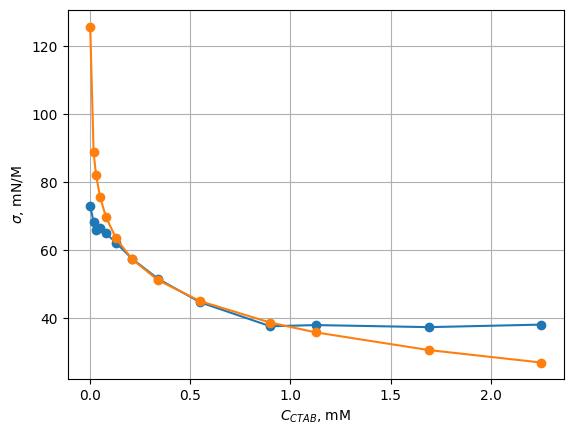

In [34]:
plt.plot(c_mm, sigma_data, 'o-')
plt.plot(c_mm, approx(np.array(c_mm)*10**-3, 16227)*10**3, 'o-')
plt.grid()
plt.xlabel(r"$C_{CTAB}$, mM")
plt.ylabel(r"$\sigma$, mN/M")
plt.savefig("img1.png")

(np.float64(-12.850928451344304), np.float64(36.78781922067199))

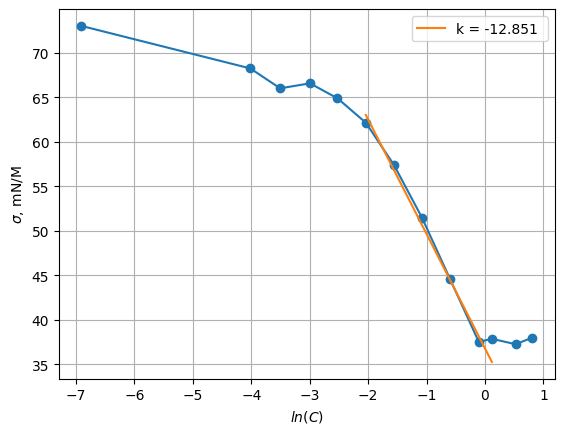

In [305]:
plt.plot(np.log(c_mm), sigma_data, 'o-')
plt.grid()
plt.xlabel(r"$ln(C)$")
plt.ylabel(r"$\sigma$, mN/M")
k, b = np.polyfit(np.log(c_mm)[-8:-3], sigma_data[-8:-3], 1)
plt.plot(np.log(c_mm)[-8:-2:5], np.log(c_mm)[-8:-2:5]*k + b, label=f'k = {round(k, 3)} ')
# plt.figure(figsize=(20, 7))
plt.legend()
plt.savefig("img2.svg")
k, b

In [341]:
g = []
for i in range(8):
    d_sigma = sigma_data[i:i+3]
    d_lnc = np.log(c_mm[i:i+3])
    k, b = np.polyfit(d_lnc, d_sigma, 1)
    g.append(-k/(298*8.314))
g

[np.float64(0.0007751300308362232),
 np.float64(0.0006618338261288495),
 np.float64(0.0004465763770934196),
 np.float64(0.0018678825185836367),
 np.float64(0.0031192456961661795),
 np.float64(0.004475957916853012),
 np.float64(0.005384029023867453),
 np.float64(0.005788360366026746)]

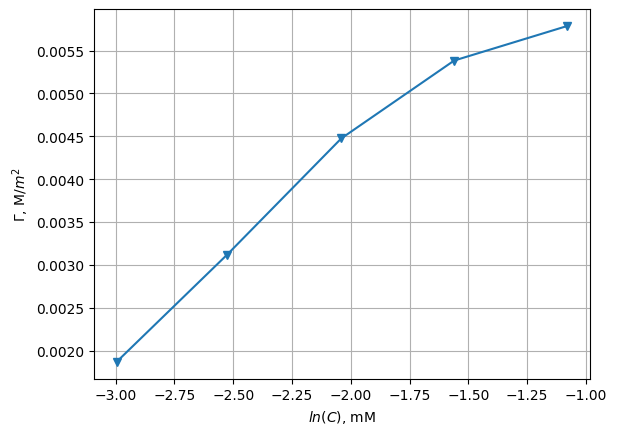

In [342]:
plt.plot(np.log(c_mm[3:8]), g[3:], 'v-')
plt.grid()
plt.xlabel(r"$ln(C)$, mM")
plt.ylabel(r"$\Gamma$, M/$m^2$")
plt.savefig("img3.svg")

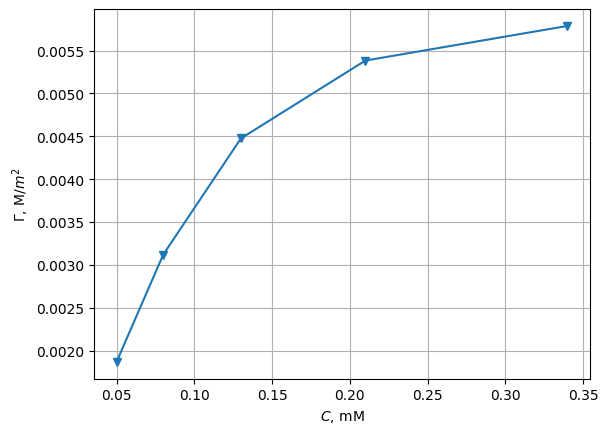

In [344]:
plt.plot((c_mm[3:8]), g[3:], 'v-')
plt.grid()
plt.xlabel(r"$C$, mM")
plt.ylabel(r"$\Gamma$, M/$m^2$")
plt.savefig("img4.svg")

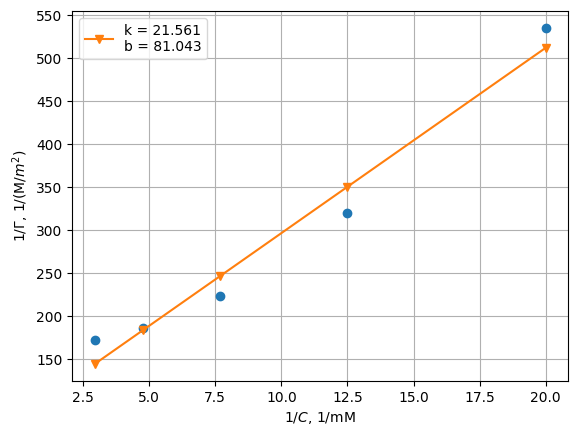

In [368]:
k, b = np.polyfit(1/np.array(c_mm[3:8]), 1/np.array(g[3:]), 1)
plt.plot(1/np.array(c_mm[3:8]), 1/np.array(g[3:]), 'o')
plt.plot(1/np.array(c_mm[3:8]), k/np.array(c_mm[3:8]) + b, 'v-', label=f'k = {round(k, 3)}\nb = {round(b, 3)}')
plt.legend()
plt.grid()
plt.xlabel(r"$1/C$, 1/mM")
plt.ylabel(r"$1/\Gamma$, 1/(M/$m^2$)")
plt.savefig("img5.svg")